# Import Scripts and Load the Merged Data

In [1]:
import os
import sys

PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
from src.data.build_dataset import build_market_dataset

df = build_market_dataset()
df.head()

,date,SPY,QQQ,DIA,IWN
0,2002-01-03,1.127519,3.406775,0.975425,1.156449
1,2002-01-04,0.665375,0.408802,0.857495,0.847332
2,2002-01-07,-0.708118,-1.110050,-0.612907,-1.100651
3,2002-01-08,-0.231511,0.677149,-0.457057,0.803877
4,2002-01-09,-0.818595,-0.920103,-0.557779,-0.389629


In [3]:
df.shape

(6021, 5)

In [4]:
df.describe()

,date,SPY,QQQ,DIA,IWN
count,6021,6021.000000,6021.000000,6021.000000,6021.000000
mean,2014-01-16 08:07:24.843049472,0.039695,0.047040,0.026213,0.033360
min,2002-01-03 00:00:00,-11.588661,-12.759215,-13.841813,-14.064349
25%,2008-01-03 00:00:00,-0.422976,-0.591504,-0.436183,-0.686882
50%,2013-12-24 00:00:00,0.071503,0.114323,0.053446,0.068304
75%,2020-02-24 00:00:00,0.587825,0.760659,0.549566,0.809751
max,2026-02-19 00:00:00,19.985740,11.479906,10.764325,9.062167
std,NaN,1.230961,1.438580,1.146539,1.518730


<Axes: >

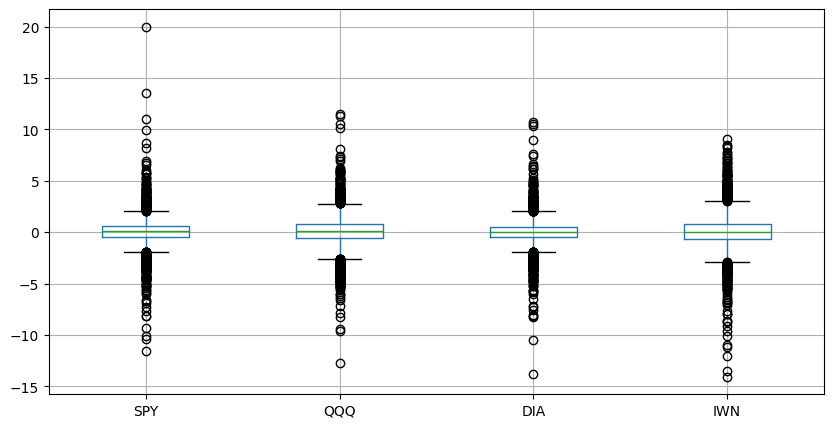

In [5]:
df.boxplot(figsize=(10,5))

we can see many assymetric tails and outliers beyond whiskers, which is our motivation to do flexible innovations

# Base VAR Test

In [6]:
from src.models.base_var import BaseVAR

var = BaseVAR(p=2, intercept=True)
design = var.build_design(df)

print("X shape:", design.X.shape)
print("Y shape:", design.Y.shape)
print("Dates shape:", design.dates.shape)
print("First 10 feature names:", design.feature_names[:10])

X shape: (6019, 9)
Y shape: (6019, 4)
Dates shape: (6019,)
First 10 feature names: ['intercept', 'SPY_lag1', 'QQQ_lag1', 'DIA_lag1', 'IWN_lag1', 'SPY_lag2', 'QQQ_lag2', 'DIA_lag2', 'IWN_lag2']


# Gaussian VAR w/ OLS

In [9]:
from src.models.gaussian_var import GaussianVAR

model = GaussianVAR(p=2, intercept=True)
result = model.fit(df)
model.summary()

{'p': 2,
 'intercept': True,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_shape': (4, 9),
 'sigma_shape': (4, 4)}

In [10]:
result.beta

array([[ 0.04311883, -0.1029961 ,  0.06385784, -0.11649409,  0.0506284 ,
        -0.15856426,  0.03770797,  0.10461545,  0.01598129],
       [ 0.0508339 , -0.06736029,  0.04724364, -0.14437008,  0.03799702,
        -0.06919901, -0.01367544,  0.04324064,  0.02465317],
       [ 0.02911379, -0.04233525,  0.05104918, -0.16824403,  0.04356329,
        -0.13023644,  0.02619027,  0.09074788,  0.01830084],
       [ 0.03615277, -0.02674738,  0.02883894, -0.11921913, -0.00435677,
        -0.10383296,  0.01271791,  0.15804461, -0.02301459]])

In [11]:
result.sigma

array([[1.49909795, 1.55237343, 1.30805722, 1.55111705],
       [1.55237343, 2.04912709, 1.36198586, 1.59823901],
       [1.30805722, 1.36198586, 1.29636837, 1.46314855],
       [1.55111705, 1.59823901, 1.46314855, 2.28447442]])

In [13]:
import pandas as pd

resid_df = pd.DataFrame(
    result.residuals,
    columns=["SPY", "QQQ", "DIA", "IWN"]
)

resid_df.head()

,SPY,QQQ,DIA,IWN
0,-0.722021,-0.989853,-0.579428,-1.078674
1,-0.305513,0.578061,-0.532025,0.650799
2,-1.011459,-1.125598,-0.730566,-0.490362
3,0.299072,0.519585,-0.374976,0.004374
4,-1.089657,-1.416004,-0.915524,-1.083217


In [15]:
resid_df.kurtosis()

SPY    22.566209
QQQ     5.637562
DIA    12.693664
IWN     7.510998
dtype: float64

Kurtosis > 3, justifies use of T-Var

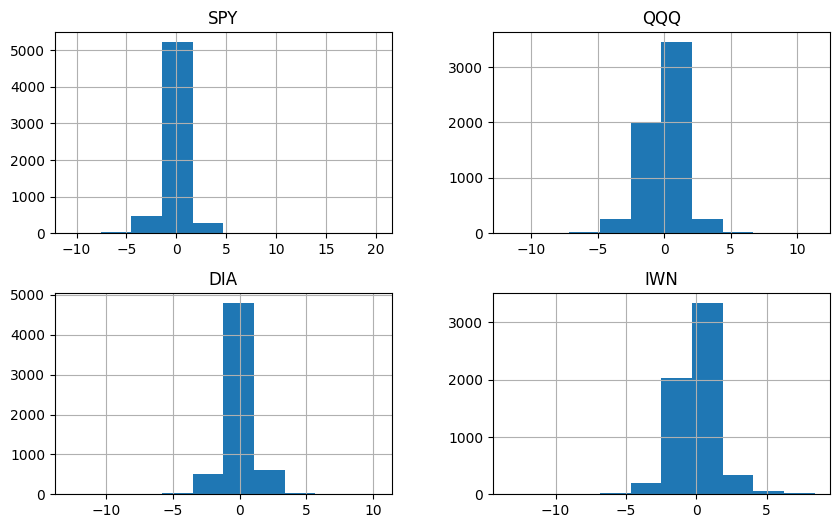

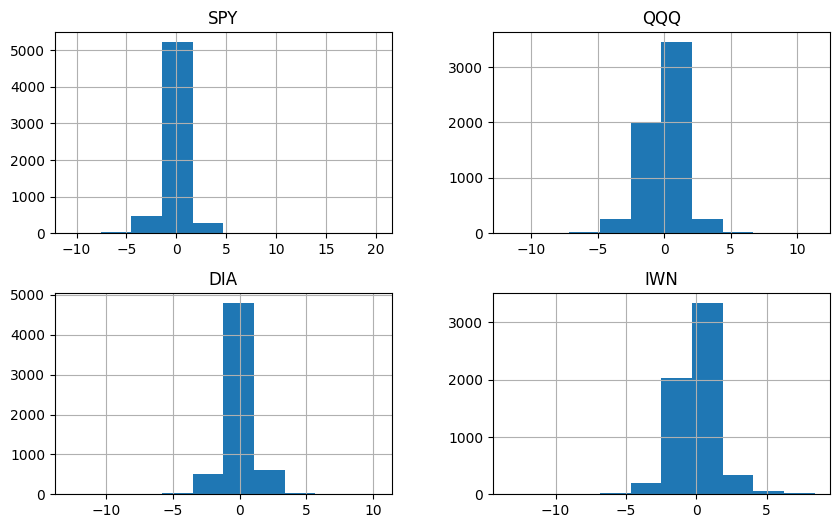

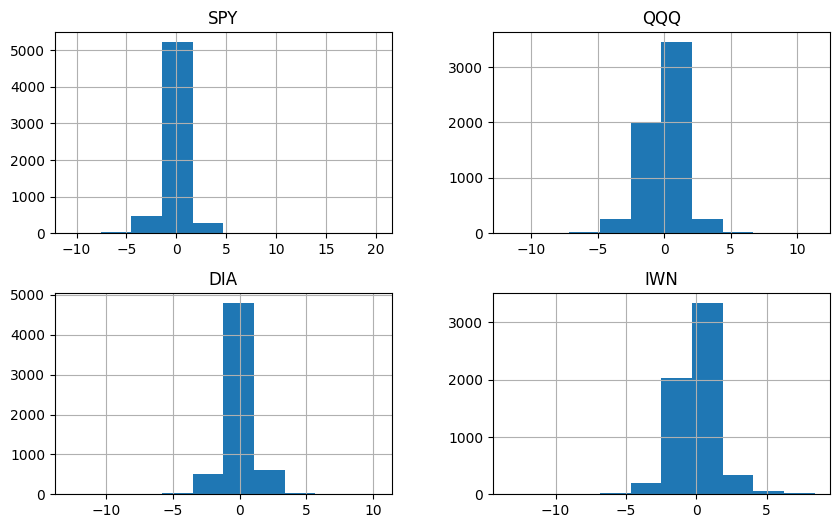

In [16]:
import matplotlib.pyplot as plt

resid_df.hist(figsize=(10, 6))
plt.show()

# Student t-VAR

In [17]:
from src.data.build_dataset import build_market_dataset
from src.models.student_t_var import StudentTVAR

df = build_market_dataset()

model_t = StudentTVAR(p=2, intercept=True, nu=8, seed=123)
result_t = model_t.fit(df, n_iter=800, burn=300)

model_t.summary()

/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/student_t_var.py:81: RuntimeWarning: divide by zero encountered in matmul
  residuals = Y - X @ beta_t
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/student_t_var.py:81: RuntimeWarning: overflow encountered in matmul
  residuals = Y - X @ beta_t
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/student_t_var.py:81: RuntimeWarning: invalid value encountered in matmul
  residuals = Y - X @ beta_t
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/student_t_var.py:104: RuntimeWarning: divide by zero encountered in matmul
  fitted_values = X @ beta_t
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/student_t_var.py:104: RuntimeWarning: overflow encountered in matmul
  fitted_values = X @ beta_t
/Users/jona

{'p': 2,
 'intercept': True,
 'nu': 8.0,
 'n_saved_draws': 500,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_draw_shape': (4, 9),
 'sigma_draw_shape': (4, 4)}